# Week 5: Feature Extraction & Engineering

**Goal:** Extract hand-crafted audio features from every RAVDESS file using librosa, save the feature matrix to CSV, and analyze which features best separate the emotion classes.

**Deliverable:** `data/features.csv` + this EDA notebook.

---
## Feature Checklist (required)
- [ ] MFCCs (13 coefficients) — mean + std per coefficient = 26 features
- [ ] MFCC Deltas (1st order) — mean + std = 26 features
- [ ] MFCC Delta-Deltas (2nd order) — mean + std = 26 features
- [ ] Chroma features — mean + std = 24 features
- [ ] Mel Spectrogram — mean + std per mel band
- [ ] Zero Crossing Rate — mean + std = 2 features
- [ ] RMS Energy — mean + std = 2 features
- [ ] Spectral Centroid — mean + std = 2 features
- [ ] Spectral Bandwidth — mean + std = 2 features
- [ ] Spectral Rolloff — mean + std = 2 features

**Important:** fit StandardScaler on training data only — never on the full dataset.

## Outline
1. Imports & load metadata
2. Single-file feature extraction (build & verify)
3. Batch extraction → features.csv
4. Feature analysis (distributions, correlations)
5. Standardization (train/test split + StandardScaler)
6. Save arrays for downstream notebooks
7. Discussion

In [47]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings
import importlib
import minilearn.preprocessing
importlib.reload(minilearn.preprocessing)
from minilearn.preprocessing import StandardScaler, train_test_split
warnings.filterwarnings('ignore')

# Make minilearn importable from the notebooks/ folder
sys.path.insert(0, os.path.abspath('..'))

DATA_DIR   = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\data'
OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Load metadata produced in Week 4 ──────────────────────────────────────
EMOTION_MAP = {
    1: 'neutral',  2: 'calm',     3: 'happy',    4: 'sad',
    5: 'angry',    6: 'fearful',  7: 'disgust',  8: 'surprised'
}
emotion_order = [EMOTION_MAP[i] for i in range(1, 9)]

meta_path = os.path.join(DATA_DIR, 'metadata.csv')
df = pd.read_csv(meta_path)
df['emotion_label'] = pd.Categorical(
    df['emotion_label'], categories=emotion_order, ordered=True
)

print(f'Loaded {len(df)} files from metadata.csv')
df.head(3)

Loaded 2452 files from metadata.csv


,path,modality,vocal_channel,channel_label,emotion,emotion_label,intensity,statement,repetition,actor,gender
0,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,1,neutral,1,1,1,1,male
1,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,1,neutral,1,1,2,1,male
2,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,1,neutral,1,2,1,1,male


## 1. Feature Extraction Pipeline

In [48]:
def extract_features(filepath, sr=48000, n_mfcc=13):
    """
    Load one audio file and return a 1-D feature vector.

    Every feature matrix has shape (k, n_frames).  We compute
    mean and std across the frame axis (axis=1) to get a
    fixed-length 2k vector, then concatenate all vectors.

    Final vector length:
        MFCCs          : 13 mean + 13 std =  26
        MFCC deltas    : 13 mean + 13 std =  26
        MFCC delta2    : 13 mean + 13 std =  26
        Chroma         : 12 mean + 12 std =  24
        ZCR            :  1 mean +  1 std =   2
        RMS            :  1 mean +  1 std =   2
        Spectral cent. :  1 mean +  1 std =   2
        Spectral bw    :  1 mean +  1 std =   2
        Spectral roll  :  1 mean +  1 std =   2
                                        ------
                                    Total = 112 features

    Parameters
    ----------
    filepath : str   — path to a .wav file
    sr       : int   — target sample rate (48000 = RAVDESS native)
    n_mfcc   : int   — number of MFCC coefficients

    Returns
    -------
    np.ndarray, shape (112,)
    """
    # ── Load audio ─────────────────────────────────────────────────────────
    # sr=sr resamples to the target rate; mono=True averages stereo channels
    y, sr = librosa.load(filepath, sr=sr, mono=True)

    # ── Helper: mean + std over time axis → flat vector ────────────────────
    # Input shape: (k, n_frames)  →  Output shape: (2k,)
    def summarize(matrix):
        return np.concatenate([
            np.mean(matrix, axis=1),
            np.std(matrix,  axis=1)
        ])

    # ── MFCCs ──────────────────────────────────────────────────────────────
    # Shape: (n_mfcc, n_frames) = (13, ~235) for a 3-second clip at 48kHz
    mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # ── MFCC deltas (1st-order difference across frames) ───────────────────
    # Captures HOW the spectrum changes — important for dynamic emotions
    mfcc_delta  = librosa.feature.delta(mfcc, order=1)

    # ── MFCC delta-deltas (2nd-order) ──────────────────────────────────────
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # ── Chroma (12 pitch classes, e.g. C, C#, D, ...) ─────────────────────
    # Computed from the Short-Time Fourier Transform
    chroma      = librosa.feature.chroma_stft(y=y, sr=sr)

    # ── Zero Crossing Rate ─────────────────────────────────────────────────
    # How often the signal crosses zero — proxy for noisiness/energy
    # Shape: (1, n_frames)
    zcr         = librosa.feature.zero_crossing_rate(y)

    # ── RMS Energy ─────────────────────────────────────────────────────────
    # Root mean square energy per frame — proxy for loudness
    rms         = librosa.feature.rms(y=y)

    # ── Spectral features ──────────────────────────────────────────────────
    # All return shape (1, n_frames)
    centroid    = librosa.feature.spectral_centroid(y=y,  sr=sr)
    bandwidth   = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff     = librosa.feature.spectral_rolloff(y=y,   sr=sr)

    # ── Concatenate all summaries into one vector ──────────────────────────
    feature_vector = np.concatenate([
        summarize(mfcc),        # 26
        summarize(mfcc_delta),  # 26
        summarize(mfcc_delta2), # 26
        summarize(chroma),      # 24
        summarize(zcr),         #  2
        summarize(rms),         #  2
        summarize(centroid),    #  2
        summarize(bandwidth),   #  2
        summarize(rolloff),     #  2
    ])

    return feature_vector

In [49]:
# ── Verify on a single file before running the full batch ─────────────────
test_path = df['path'].iloc[0]
test_vec  = extract_features(test_path)

print(f'Test file     : {os.path.basename(test_path)}')
print(f'Feature shape : {test_vec.shape}')   # should be (112,)
print(f'Any NaN?      : {np.isnan(test_vec).any()}')
print(f'Any Inf?      : {np.isinf(test_vec).any()}')
print(f'\nFirst 10 values: {test_vec[:10].round(4)}')

Test file     : 03-02-01-01-01-01-01.wav
Feature shape : (112,)
Any NaN?      : False
Any Inf?      : False

First 10 values: [-625.1063   86.0088  -14.9087   11.6129    0.9515    9.4994   -8.3601
   -3.4052   -9.2187   -6.5603]


## 3. Batch Extraction → features.csv

Now run `extract_features` on all 2,452 files.

**Expected runtime:** ~5–15 minutes depending on your machine.  
We print progress every 200 files and skip any file that errors rather than crashing the whole run.

In [50]:
# ── Build column names so the CSV is self-documenting ─────────────────────
# Each feature group gets mean_X and std_X names.
def make_col_names():
    cols = []
    for stat in ['mean', 'std']:
        for i in range(13): cols.append(f'mfcc_{stat}_{i+1}')
    for stat in ['mean', 'std']:
        for i in range(13): cols.append(f'mfcc_delta_{stat}_{i+1}')
    for stat in ['mean', 'std']:
        for i in range(13): cols.append(f'mfcc_delta2_{stat}_{i+1}')
    for stat in ['mean', 'std']:
        for i in range(12): cols.append(f'chroma_{stat}_{i+1}')
    for feat in ['zcr', 'rms', 'centroid', 'bandwidth', 'rolloff']:
        cols.append(f'{feat}_mean')
        cols.append(f'{feat}_std')
    return cols

FEATURE_COLS = make_col_names()
print(f'Total feature columns: {len(FEATURE_COLS)}')
print('First 5:', FEATURE_COLS[:5])
print('Last  5:', FEATURE_COLS[-5:])

Total feature columns: 112
First 5: ['mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4', 'mfcc_mean_5']
Last  5: ['centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'rolloff_std']


In [51]:
# ── Main extraction loop ───────────────────────────────────────────────────
features_list = []
failed        = []

for i, row in df.iterrows():
    try:
        vec = extract_features(row['path'])
        features_list.append(vec)
    except Exception as e:
        print(f'  ERROR on {os.path.basename(row["path"])}: {e}')
        features_list.append(np.full(len(FEATURE_COLS), np.nan))
        failed.append(row['path'])

    if (i + 1) % 200 == 0:
        print(f'  Processed {i+1}/{len(df)} files...')

print(f'\nDone. Failed files: {len(failed)}')

# ── Assemble DataFrame ─────────────────────────────────────────────────────
feat_df = pd.DataFrame(features_list, columns=FEATURE_COLS)

# Attach metadata columns we'll need downstream
feat_df['emotion']       = df['emotion'].values        # numeric label (1–8)
feat_df['emotion_label'] = df['emotion_label'].values
feat_df['vocal_channel'] = df['vocal_channel'].values  # 1=speech, 2=song
feat_df['actor']         = df['actor'].values
feat_df['gender']        = df['gender'].values

# Drop any rows that failed extraction
n_before = len(feat_df)
feat_df.dropna(subset=FEATURE_COLS[:1], inplace=True)
print(f'Rows kept: {len(feat_df)} / {n_before}')

feat_df.head(3)

  Processed 200/2452 files...
  Processed 400/2452 files...
  Processed 600/2452 files...
  Processed 800/2452 files...
  Processed 1000/2452 files...
  Processed 1200/2452 files...
  Processed 1400/2452 files...
  Processed 1600/2452 files...
  Processed 1800/2452 files...
  Processed 2000/2452 files...
  Processed 2200/2452 files...
  Processed 2400/2452 files...

Done. Failed files: 0
Rows kept: 2452 / 2452


,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,mfcc_mean_10,...,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,emotion,emotion_label,vocal_channel,actor,gender
0,-625.106262,86.008797,-14.908678,11.612943,0.951541,9.499438,-8.360124,-3.405227,-9.218716,-6.560265,...,4446.253226,4061.641247,2431.813216,8991.578989,8019.303774,1,neutral,2,1,male
1,-599.416138,84.052719,-15.714040,11.429276,0.850099,9.990978,-9.621907,-4.252555,-8.429587,-6.368863,...,4512.875803,4105.791813,2416.589503,9049.622039,8031.474060,1,neutral,2,1,male
2,-612.903076,82.196556,-13.120657,14.789132,3.518427,7.586631,-6.735970,-2.411212,-8.073819,-7.083177,...,4472.867907,4305.516765,2427.057734,9675.801180,8052.229491,1,neutral,2,1,male


In [52]:
# ── Save to CSV ────────────────────────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'features.csv')
feat_df.to_csv(out_path, index=False)
print(f'Saved {feat_df.shape[0]} rows × {feat_df.shape[1]} cols → {out_path}')

Saved 2452 rows × 117 cols → C:\Users\Grana\Documents\GitHub\Project_CSE432_MG\Project_CSE432-532\SER_Project\output\features.csv


## 4. Feature Analysis

Before modeling, we explore whether our features actually separate the emotion classes.
A feature that looks identical across all 8 emotions is useless — we want features
where the class distributions are clearly different.

We'll look at three things:
1. **MFCC distributions per emotion** — the most informative features
2. **Correlation heatmap** — identify redundant features
3. **Feature variance** — flag near-zero variance columns

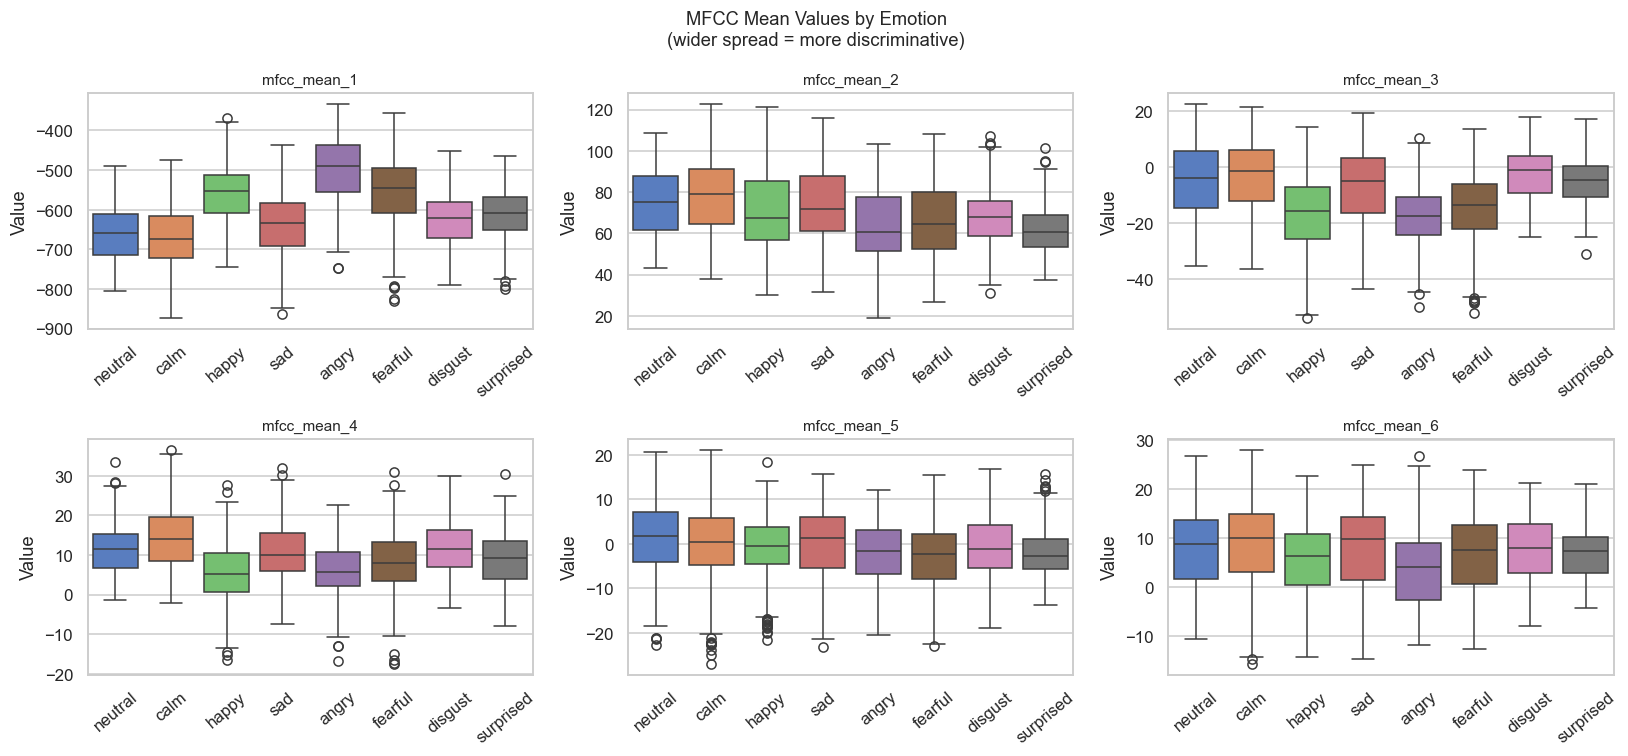

In [53]:
# ── Plot A: MFCC mean distributions per emotion ────────────────────────────
# Show the first 6 MFCC means — these carry the most energy
mfcc_mean_cols = [f'mfcc_mean_{i}' for i in range(1, 7)]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for idx, col in enumerate(mfcc_mean_cols):
    sns.boxplot(
        data=feat_df, x='emotion_label', y=col,
        order=emotion_order, palette='muted', ax=axes[idx]
    )
    axes[idx].set_title(f'{col}', fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Value')
    axes[idx].tick_params(axis='x', rotation=40)

plt.suptitle('MFCC Mean Values by Emotion\n'
             '(wider spread = more discriminative)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mfcc_distributions.png'), bbox_inches='tight')
plt.show()

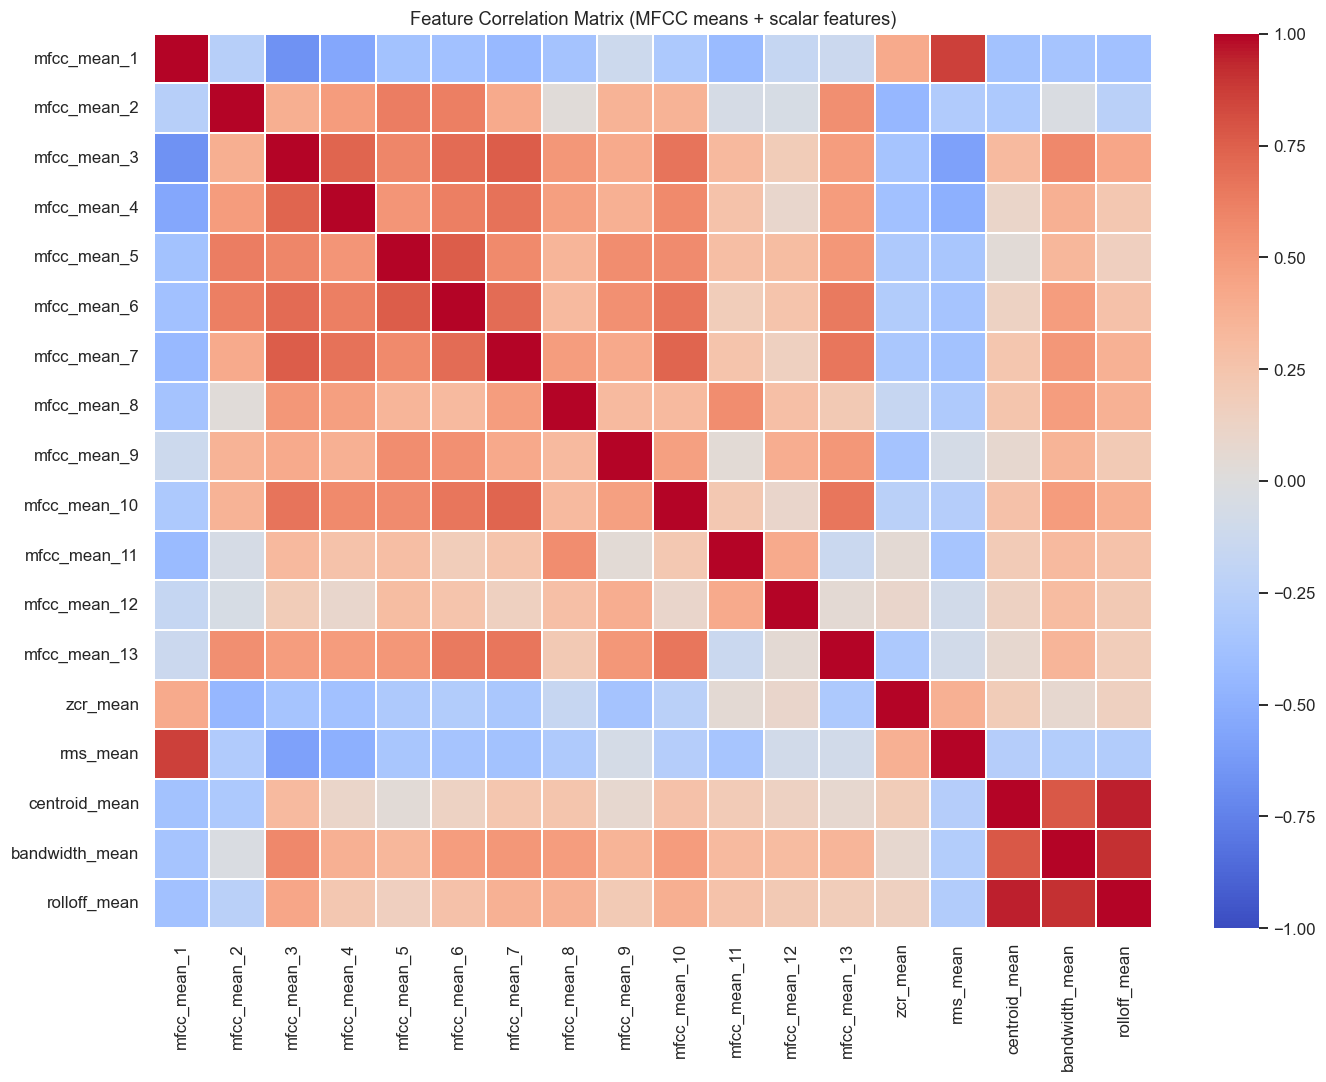

Top 10 most correlated feature pairs:
centroid_mean   rolloff_mean      0.952
bandwidth_mean  rolloff_mean      0.912
mfcc_mean_1     rms_mean          0.861
centroid_mean   bandwidth_mean    0.776
mfcc_mean_5     mfcc_mean_6       0.761
mfcc_mean_3     mfcc_mean_7       0.760
mfcc_mean_7     mfcc_mean_10      0.734
mfcc_mean_3     mfcc_mean_4       0.731
                mfcc_mean_6       0.710
mfcc_mean_6     mfcc_mean_7       0.698
dtype: float64


In [54]:
# ── Plot B: Feature correlation heatmap ────────────────────────────────────
# High correlation (|r| > 0.9) means two features carry nearly identical information.
# PCA (Week 12) will handle redundancy — but it's useful to see it now.

# Use a representative subset: all MFCC means + scalar features
subset_cols = (
    [f'mfcc_mean_{i}' for i in range(1, 14)] +
    ['zcr_mean', 'rms_mean', 'centroid_mean', 'bandwidth_mean', 'rolloff_mean']
)

corr = feat_df[subset_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, annot=False, cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.3, ax=ax
)
ax.set_title('Feature Correlation Matrix (MFCC means + scalar features)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_correlation.png'), bbox_inches='tight')
plt.show()

# Flag highly correlated pairs
high_corr = (
    corr.abs()
       .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
       .stack()
       .sort_values(ascending=False)
)
print('Top 10 most correlated feature pairs:')
print(high_corr.head(10).round(3))

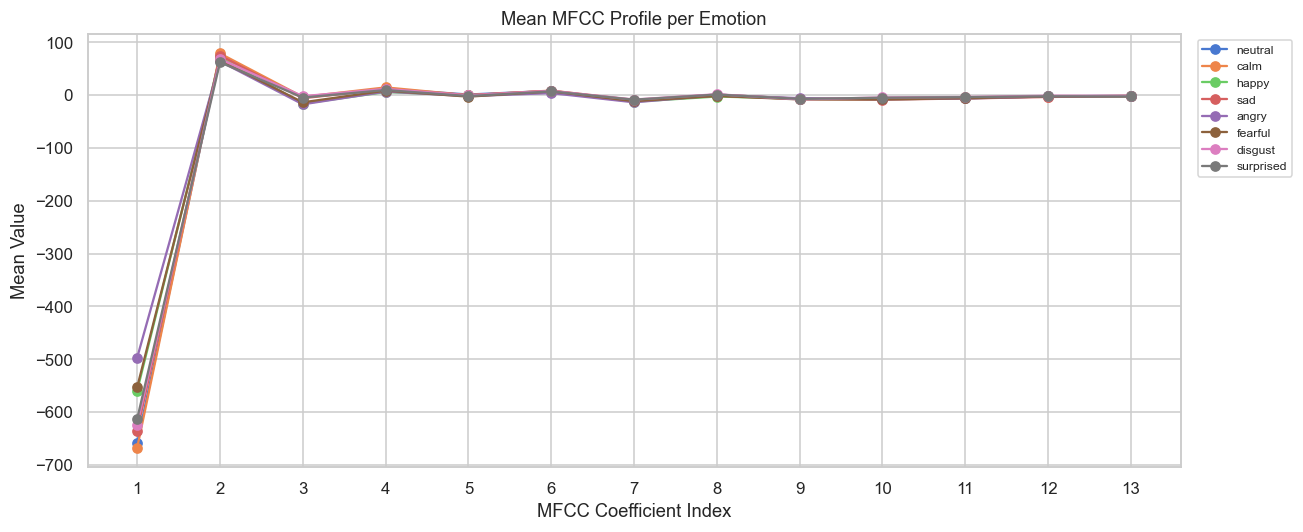

In [55]:
# ── Plot C: Per-emotion mean feature profiles ──────────────────────────────
# Shows the average value of each MFCC mean coefficient per emotion.
# Emotions with different 'shapes' across coefficients are easier to separate.

mfcc_mean_cols_all = [f'mfcc_mean_{i}' for i in range(1, 14)]

profile = feat_df.groupby('emotion_label', observed=True)[mfcc_mean_cols_all].mean()

fig, ax = plt.subplots(figsize=(12, 5))
for emotion in emotion_order:
    ax.plot(range(1, 14), profile.loc[emotion], marker='o',
            label=emotion, linewidth=1.5)

ax.set_title('Mean MFCC Profile per Emotion')
ax.set_xlabel('MFCC Coefficient Index')
ax.set_ylabel('Mean Value')
ax.set_xticks(range(1, 14))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mfcc_profiles.png'), bbox_inches='tight')
plt.show()

In [56]:
# ── Near-zero variance check ────────────────────────────────────────────────
# Features with almost no variance carry no discriminative signal.
variances = feat_df[FEATURE_COLS].var().sort_values()
low_var = variances[variances < 0.01]

print(f'Features with variance < 0.01: {len(low_var)}')
if len(low_var) > 0:
    print(low_var)
else:
    print('None — all features have meaningful variance. ✓')

Features with variance < 0.01: 47
mfcc_delta2_mean_13    0.000021
mfcc_delta2_mean_12    0.000024
mfcc_delta2_mean_11    0.000027
mfcc_delta2_mean_10    0.000032
mfcc_delta2_mean_8     0.000034
mfcc_delta2_mean_7     0.000036
mfcc_delta2_mean_9     0.000037
mfcc_delta2_mean_6     0.000042
mfcc_delta2_mean_5     0.000046
mfcc_delta2_mean_4     0.000063
mfcc_delta2_mean_3     0.000102
mfcc_delta_mean_13     0.000102
mfcc_delta_mean_12     0.000131
mfcc_delta_mean_11     0.000144
rms_mean               0.000147
mfcc_delta_mean_8      0.000176
mfcc_delta_mean_7      0.000208
mfcc_delta_mean_10     0.000218
mfcc_delta_mean_6      0.000252
zcr_std                0.000254
mfcc_delta_mean_9      0.000256
rms_std                0.000296
mfcc_delta_mean_5      0.000302
mfcc_delta2_mean_2     0.000311
zcr_mean               0.000312
mfcc_delta_mean_4      0.000453
mfcc_delta2_mean_1     0.000522
chroma_std_5           0.000672
chroma_std_4           0.000744
chroma_std_7           0.000785
chroma

## 5. Feature Standardization

Audio features live on wildly different scales:
- MFCC values: roughly –200 to +100
- Spectral centroid: roughly 500 to 4000 Hz
- ZCR: roughly 0.01 to 0.3

Without standardization, KNN's distance computation is dominated by the largest-scale features (centroid, rolloff), and gradient-based models (Logistic Regression) converge slowly.

**Critical rule:** fit the scaler on training data **only**, then apply the same
fitted scaler to the test set. Fitting on test data would leak information about
the test distribution into training — a form of data leakage that inflates metrics.

In [57]:
from minilearn.preprocessing import StandardScaler, train_test_split

# ── Separate features from labels ─────────────────────────────────────────
X = feat_df[FEATURE_COLS].values.astype(float)   # shape: (n_samples, 112)
y = feat_df['emotion'].values.astype(int)         # shape: (n_samples,), values 1–8

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Classes: {np.unique(y)}')
print(f'Class counts: {dict(zip(*np.unique(y, return_counts=True)))}')

X shape: (2452, 112)
y shape: (2452,)
Classes: [1 2 3 4 5 6 7 8]
Class counts: {np.int64(1): np.int64(188), np.int64(2): np.int64(376), np.int64(3): np.int64(376), np.int64(4): np.int64(376), np.int64(5): np.int64(376), np.int64(6): np.int64(376), np.int64(7): np.int64(192), np.int64(8): np.int64(192)}


In [58]:
# ── Stratified train/test split ────────────────────────────────────────────
# stratify=True ensures each emotion class appears proportionally in both sets.
# random_state=42 makes the split reproducible — use the same seed everywhere.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=True
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')

# Verify class proportions are preserved
print('\nClass proportions (train vs test):')
for cls in np.unique(y):
    train_pct = (y_train == cls).mean()
    test_pct  = (y_test  == cls).mean()
    label     = EMOTION_MAP[cls]
    print(f'  {label:<12}: train={train_pct:.3f}  test={test_pct:.3f}')

Train: 1956 samples
Test : 496 samples

Class proportions (train vs test):
  neutral     : train=0.077  test=0.077
  calm        : train=0.153  test=0.153
  happy       : train=0.153  test=0.153
  sad         : train=0.153  test=0.153
  angry       : train=0.153  test=0.153
  fearful     : train=0.153  test=0.153
  disgust     : train=0.078  test=0.079
  surprised   : train=0.078  test=0.079


In [59]:
# ── Fit scaler on train, transform both ────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # transform only — no refit!

print('Before scaling:')
print(f'  Train mean range: [{X_train.mean(axis=0).min():.1f}, {X_train.mean(axis=0).max():.1f}]')
print(f'  Train std  range: [{X_train.std(axis=0).min():.3f},  {X_train.std(axis=0).max():.1f}]')

print('\nAfter scaling:')
print(f'  Train mean range: [{X_train_scaled.mean(axis=0).min():.6f}, {X_train_scaled.mean(axis=0).max():.6f}]')
print(f'  Train std  range: [{X_train_scaled.std(axis=0).min():.3f},  {X_train_scaled.std(axis=0).max():.3f}]')

# Train should be ~[0,0] mean and ~[1,1] std — test will be close but not exact
print(f'\n  Test mean range (not fitted): [{X_test_scaled.mean(axis=0).min():.4f}, {X_test_scaled.mean(axis=0).max():.4f}]')

Before scaling:
  Train mean range: [-594.2, 10060.6]
  Train std  range: [0.005,  1688.6]

After scaling:
  Train mean range: [-0.000000, 0.000000]
  Train std  range: [1.000,  1.000]

  Test mean range (not fitted): [-0.0941, 0.1344]


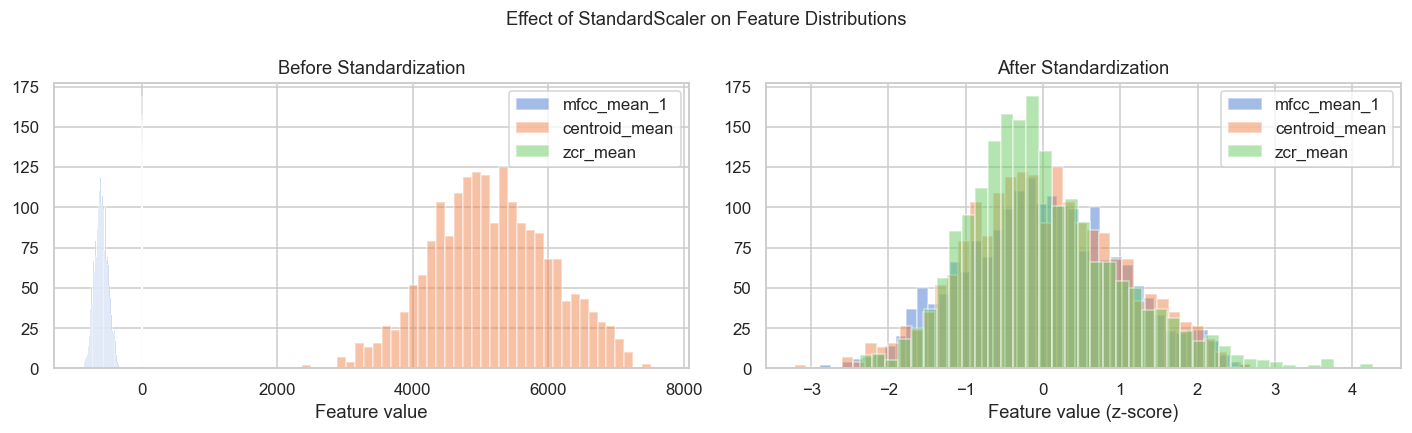

In [60]:
# ── Before/After scaling visualization ────────────────────────────────────
# Picking a few features with very different original scales to illustrate
# the effect of standardization clearly.
demo_indices = {
    'mfcc_mean_1'    : FEATURE_COLS.index('mfcc_mean_1'),
    'centroid_mean'  : FEATURE_COLS.index('centroid_mean'),
    'zcr_mean'       : FEATURE_COLS.index('zcr_mean'),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, idx in demo_indices.items():
    axes[0].hist(X_train[:, idx], bins=40, alpha=0.5, label=name)
    axes[1].hist(X_train_scaled[:, idx], bins=40, alpha=0.5, label=name)

axes[0].set_title('Before Standardization')
axes[0].set_xlabel('Feature value')
axes[0].legend()
axes[1].set_title('After Standardization')
axes[1].set_xlabel('Feature value (z-score)')
axes[1].legend()

plt.suptitle('Effect of StandardScaler on Feature Distributions', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scaling_effect.png'), bbox_inches='tight')
plt.show()

In [61]:
# ── Stratified train/test split ────────────────────────────────────────────
# stratify=True ensures each emotion class appears proportionally in both sets.
# random_state=42 makes the split reproducible — use the same seed everywhere.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=True
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')

# Verify class proportions are preserved
print('\nClass proportions (train vs test):')
for cls in np.unique(y):
    train_pct = (y_train == cls).mean()
    test_pct  = (y_test  == cls).mean()
    label     = EMOTION_MAP[cls]
    print(f'  {label:<12}: train={train_pct:.3f}  test={test_pct:.3f}')

Train: 1956 samples
Test : 496 samples

Class proportions (train vs test):
  neutral     : train=0.077  test=0.077
  calm        : train=0.153  test=0.153
  happy       : train=0.153  test=0.153
  sad         : train=0.153  test=0.153
  angry       : train=0.153  test=0.153
  fearful     : train=0.153  test=0.153
  disgust     : train=0.078  test=0.079
  surprised   : train=0.078  test=0.079


## 6. Save Arrays for Downstream Notebooks

All later notebooks (Week 7 onward) load these `.npy` files directly —
no re-extraction or re-splitting needed.
The same train/test split is reused throughout to ensure fair comparisons.

In [62]:
np.save(os.path.join(OUTPUT_DIR, 'X_train.npy'),        X_train_scaled)
np.save(os.path.join(OUTPUT_DIR, 'X_test.npy'),         X_test_scaled)
np.save(os.path.join(OUTPUT_DIR, 'y_train.npy'),        y_train)
np.save(os.path.join(OUTPUT_DIR, 'y_test.npy'),         y_test)
np.save(os.path.join(OUTPUT_DIR, 'X_train_raw.npy'),    X_train)   # unscaled, for regression
np.save(os.path.join(OUTPUT_DIR, 'X_test_raw.npy'),     X_test)

# Save scaler parameters so we can re-apply to new data if needed
np.save(os.path.join(OUTPUT_DIR, 'scaler_mean.npy'),    scaler.mean_)
np.save(os.path.join(OUTPUT_DIR, 'scaler_std.npy'),     scaler.std_)

# Save feature column names for reference
pd.Series(FEATURE_COLS).to_csv(
    os.path.join(OUTPUT_DIR, 'feature_names.csv'), index=False, header=False
)

print('Saved:')
for fname in ['X_train.npy','X_test.npy','y_train.npy','y_test.npy',
              'X_train_raw.npy','X_test_raw.npy',
              'scaler_mean.npy','scaler_std.npy','feature_names.csv']:
    path = os.path.join(OUTPUT_DIR, fname)
    size = os.path.getsize(path) / 1024
    print(f'  {fname:<25} ({size:.1f} KB)')

Saved:
  X_train.npy               (1711.6 KB)
  X_test.npy                (434.1 KB)
  y_train.npy               (15.4 KB)
  y_test.npy                (4.0 KB)
  X_train_raw.npy           (1711.6 KB)
  X_test_raw.npy            (434.1 KB)
  scaler_mean.npy           (1.0 KB)
  scaler_std.npy            (1.0 KB)
  feature_names.csv         (1.8 KB)


## 4. Discussion

*Address:*
- *Which features show the most separation between emotion classes?*
- *Are any features highly correlated (redundant)?*
- *How many total features does your vector have?  Is that a concern for KNN or SVM?*